In [1]:
import os
from collections import OrderedDict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
import pandas as pd
import scipy.stats as sps
import pickle
from sklearn.metrics import accuracy_score
from similarity_facial_predict import process, verification_set
import sys
sys.path.append("../")
import utils
from conf import settings
np.random.seed(0)
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score
torch.cuda.set_device(1)
target_s_list = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
COPY_NUM = 5

# Early stopping reduces similarity estimation accuracy and clean test accuracy 

In [2]:
def load_lightning_model(path, archi='regnet_y_8gf', num_classes=20):
    net = getattr(models, archi)(num_classes=num_classes)
    state_dict = torch.load(path, map_location='cpu')['state_dict']
    load_state_dict = OrderedDict({})
    for k, v in state_dict.items():
        load_state_dict[k.replace("model.", "")] = v
    net.load_state_dict(load_state_dict)
    net.eval()
    return net

@torch.no_grad()
def evaluate_net(net, loader, device):
    net.to(device)
    trues, preds = [], []
    for x, y in loader:
        preds.extend(net(x.to(device)).argmax(dim=1).tolist())
        trues.extend(y.tolist())
    return accuracy_score(trues, preds)

## Load validation data and early stopping models

In [3]:
X_tensor_val, y_tensor_val = pickle.load(open(os.path.join(settings.DATA_PATH, 'facial_attribute', 'fairface_val_tensor.pkl'), 'rb'))
loader = torch.utils.data.DataLoader(utils.SubTrainDataset(X_tensor_val, y_tensor_val), shuffle=False, batch_size = 2048, num_workers=8, pin_memory=True)

wd_list = [5e-5, 5e-4, 5e-3]
early_type_list = ['early', 'nonearly']
mean_std_dict = process(data_type='diff_dist')
verify_tensor_idx, verify_tensor, num_classes, verify_label = verification_set(100, 1)
recompute_outputs = False

In [4]:
if recompute_outputs:
    early_prediction_dict, acc_dict = {}, {}
    for early_type in early_type_list:
        early_prediction_dict[early_type], acc_dict[early_type] = {}, {}
        base_path = os.path.join(settings.CASE_STUDY_CHECKPOINT_PATH, 'early_stopping', early_type)
        for wd in wd_list:
            early_prediction_dict[early_type][wd], acc_dict[early_type][wd] = {}, {}
            for s in target_s_list:
                pred_copy_list, acc_list = [], []
                for copy_id in range(COPY_NUM):
                    folder_name = f"regnet_y_8gf_wd{wd}_{s}_{copy_id}"
                    best_model_name  = sorted([f for f in os.listdir(os.path.join(base_path, folder_name)) if os.path.isfile(os.path.join(base_path, folder_name, f))])[0]
                    net = nn.Sequential(transforms.Normalize(*mean_std_dict[f'int{s}']), load_lightning_model(os.path.join(base_path, folder_name, best_model_name)))
                    with torch.no_grad():
                        pred_copy_list.append(net(verify_tensor).softmax(dim=1))
                        acc_list.append(evaluate_net(net, loader, 'cuda:1'))
                early_prediction_dict[early_type][wd][f'int{s}'] = torch.stack(pred_copy_list)
                acc_dict[early_type][wd][f'int{s}'] = acc_list
    pickle.dump((early_prediction_dict, acc_dict), open(os.path.join(settings.CASE_STUDY_RESULT_PATH, "early_stopping.pkl"), "wb"))
else:
    early_prediction_dict, acc_dict = pickle.load(open(os.path.join(settings.CASE_STUDY_RESULT_PATH, "early_stopping.pkl"), "rb"))

In [121]:
def estimation_accuracy(surrogate_outputs, query_outputs, test_s_list, true_s_list, copy_num=10):
    test_inter_list = ['int{}'.format(i) for i in test_s_list]
    true_inter_list = ['int{}'.format(i) for i in true_s_list]
    all_diff = []
    
    for k in range(copy_num):
        for i, key_true in enumerate(true_inter_list):
            tmp = np.zeros((len(test_inter_list), ))
            for j, key_test in enumerate(test_inter_list):
                dist_mean = torch.sum((query_outputs[key_true][k] - surrogate_outputs['vic'][k])**2, dim=1).cpu().numpy()
                dist_test = torch.sum((surrogate_outputs[key_test][k] - surrogate_outputs['vic'][k])**2, dim=1).cpu().numpy()
                stats, pv = sps.ttest_ind(dist_mean, dist_test)
                tmp[j] = np.abs(stats)

            pred_s = test_s_list[tmp.argmin(axis=0).item()]
            true_s = true_s_list[i]
            all_diff.append(np.round(np.abs(pred_s - true_s), 2))
            print(true_s, pred_s)
    all_diff = np.array(all_diff)
    mu_epsilon_summary = {}
    for mu in test_s_list:
        mu_epsilon_summary[mu] = len(np.where(all_diff >= mu)[0]) / len(all_diff)
    return mu_epsilon_summary, all_diff
 

In [122]:
similarity_outputs = pickle.load(open(os.path.join(settings.CASE_STUDY_RESULT_PATH, 'dataset_similarity', 'same_dist.pkl'), "rb"))
df_dict = {}
# df_dict= {'early stop':[], 'weight decay':[], 'mu':[], 'epsilon':[]}
acc_df_dict = {}
for early_type in early_type_list:
    df_dict[early_type] = {'weight decay':[], 'mu':[], 'epsilon':[]}
    acc_df_dict[early_type] = {'weight decay':[], 's':[], 'accuracy':[]}
    for wd in wd_list:
        query_outputs = early_prediction_dict[early_type][wd]
        mu_epsilon_summary, all_diff = estimation_accuracy(similarity_outputs, query_outputs, target_s_list, target_s_list, copy_num=5)
        print('*' * 100)
        print(early_type, wd)
        print(mu_epsilon_summary)
        
        print([f"{s}, {np.mean(acc_dict[early_type][wd][f'int{s}'])*100:.2f}" for s in target_s_list])
        for s in target_s_list:
            n_acc = len(acc_dict[early_type][wd][f'int{s}'])
            acc_df_dict[early_type]['weight decay'].extend([wd] * n_acc)
            acc_df_dict[early_type]['s'].extend([s] * n_acc)
            acc_df_dict[early_type]['accuracy'].extend(acc_dict[early_type][wd][f'int{s}'])
        for mu, eps in mu_epsilon_summary.items():
            if mu == 0.0:
                continue
            # df_dict['early stop'].append(True if early_type == 'early' else False)  
            # df_dict['weight decay'].append(wd)
            # df_dict['mu'].append(mu)
            # df_dict['epsilon'].append(eps)
            df_dict[early_type]['weight decay'].append(f'{wd:.0e}')
            df_dict[early_type]['mu'].append(mu)
            df_dict[early_type]['epsilon'].append(eps)

0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.4
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.4
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.4
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.4
0.8 0.4
1.0 0.4
0.0 0.0
0.2 0.2
0.4 0.4
0.6 0.4
0.8 0.4
1.0 0.4
****************************************************************************************************
early 5e-05
{0.0: 1.0, 0.2: 0.6333333333333333, 0.4: 0.4, 0.6: 0.23333333333333334, 0.8: 0.06666666666666667, 1.0: 0.0}
['0.0, 25.40', '0.2, 37.51', '0.4, 38.33', '0.6, 41.99', '0.8, 42.31', '1.0, 43.38']
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.0
0.4 0.0
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.0
0.4 0.2
0.6 0.2
0.8 0.4
1.0 0.4
****************************************************************************************************
early 0.0005
{0.0: 1.0, 0.2: 0.7333333333333333, 0.4: 0.5333333333333333, 0.6: 0.3, 0.8: 0.13333333333333333, 1.0

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

In [110]:
early_df

,weight decay,mu,epsilon
0,5e-05:.1e,0.2,0.633333
1,5e-05:.1e,0.4,0.400000
2,5e-05:.1e,0.6,0.233333
3,5e-05:.1e,0.8,0.066667
4,5e-05:.1e,1.0,0.000000
5,0.0005:.1e,0.2,0.733333
6,0.0005:.1e,0.4,0.533333
7,0.0005:.1e,0.6,0.300000
8,0.0005:.1e,0.8,0.133333
9,0.0005:.1e,1.0,0.000000


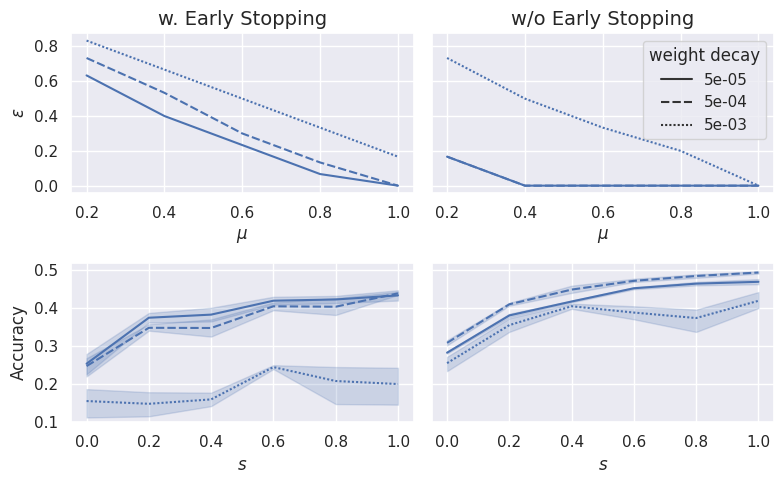

In [143]:

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(nrows=2, ncols=2, sharey='row')
fig.set_size_inches(8, 5)
sns.set_theme()

early_df = pd.DataFrame.from_dict(df_dict['early'])
sns.lineplot(x='mu', y='epsilon', style='weight decay', data=early_df, ax=ax1)
ax1.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_xlabel("$\mu$")
ax1.set_ylabel("$\epsilon$")
ax1.set_title("w. Early Stopping", fontsize=14)
ax1.get_legend().remove()

nonearly_df = pd.DataFrame.from_dict(df_dict['nonearly'])
sns.lineplot(x='mu', y='epsilon', style='weight decay', data=nonearly_df, ax=ax2)
ax2.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_xlabel("$\mu$")
ax2.set_title("w/o Early Stopping", fontsize=14)

early_acc_df = pd.DataFrame.from_dict(acc_df_dict['early'])
sns.lineplot(x='s', y='accuracy', style='weight decay', data=early_acc_df, ax=ax3)
ax3.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax3.set_xlabel("$s$")
ax3.set_ylabel("Accuracy")
ax3.set_ylim([0.1, .52])
ax3.get_legend().remove()

nonearly_acc_df = pd.DataFrame.from_dict(acc_df_dict['nonearly'])
sns.lineplot(x='s', y='accuracy', style='weight decay', data=nonearly_acc_df, ax=ax4)
ax4.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax4.set_xlabel("$s$")
# ax4.set_ylabel("Accuracy")
ax4.get_legend().remove()

plt.tight_layout()
plt.savefig("early_stopping.pdf", bbox_inches='tight')


In [129]:
np.mean(acc_dict['early'][5e-5]['int1.0']), np.mean(acc_dict['early'][5e-4]['int1.0'])

(0.43383238999452256, 0.43921855030125984)

In [132]:
np.mean(acc_dict['nonearly'][5e-5]['int1.0']), np.mean(acc_dict['nonearly'][5e-4]['int1.0'])

(0.4696001460653642, 0.4940660945773233)

In [170]:
 (np.mean(acc_dict['nonearly'][5e-4]['int1.0']) - np.mean(acc_dict['early'][5e-4]['int1.0']))/ np.mean(acc_dict['nonearly'][5e-4]['int1.0']) 

0.11101256467110114

In [152]:
similarity_outputs = pickle.load(open(os.path.join(settings.CASE_STUDY_RESULT_PATH, 'dataset_similarity', 'same_dist.pkl'), "rb"))
df_dict =  {'early stopping':[], 'weight decay':[], 'mu':[], 'epsilon':[]}
# df_dict= {'early stop':[], 'weight decay':[], 'mu':[], 'epsilon':[]}
acc_df_dict = {'early stopping':[], 'weight decay':[], 's':[], 'accuracy':[]}
for early_type in early_type_list:

    for wd in wd_list:
        query_outputs = early_prediction_dict[early_type][wd]
        mu_epsilon_summary, all_diff = estimation_accuracy(similarity_outputs, query_outputs, target_s_list, target_s_list, copy_num=5)
        print('*' * 100)
        print(early_type, wd)
        print(mu_epsilon_summary)
        
        print([f"{s}, {np.mean(acc_dict[early_type][wd][f'int{s}'])*100:.2f}" for s in target_s_list])
        for s in target_s_list:
            n_acc = len(acc_dict[early_type][wd][f'int{s}'])
            acc_df_dict['early stopping'].extend([True if early_type =='early' else False]*n_acc)
            acc_df_dict['weight decay'].extend([f'{wd:.0e}'] * n_acc)
            acc_df_dict['s'].extend([s] * n_acc)
            acc_df_dict['accuracy'].extend(acc_dict[early_type][wd][f'int{s}'])
        for mu, eps in mu_epsilon_summary.items():
            if mu == 0.0:
                continue
            # df_dict['early stop'].append(True if early_type == 'early' else False)  
            # df_dict['weight decay'].append(wd)
            # df_dict['mu'].append(mu)
            # df_dict['epsilon'].append(eps)
            df_dict['early stopping'].append(True if early_type =='early' else False)
            df_dict['weight decay'].append(f'{wd:.0e}')
            df_dict['mu'].append(mu)
            df_dict['epsilon'].append(eps)

0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.4
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.4
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.4
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.4
0.8 0.4
1.0 0.4
0.0 0.0
0.2 0.2
0.4 0.4
0.6 0.4
0.8 0.4
1.0 0.4
****************************************************************************************************
early 5e-05
{0.0: 1.0, 0.2: 0.6333333333333333, 0.4: 0.4, 0.6: 0.23333333333333334, 0.8: 0.06666666666666667, 1.0: 0.0}
['0.0, 25.40', '0.2, 37.51', '0.4, 38.33', '0.6, 41.99', '0.8, 42.31', '1.0, 43.38']
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.0
0.4 0.0
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.2
0.4 0.2
0.6 0.2
0.8 0.2
1.0 0.2
0.0 0.0
0.2 0.0
0.4 0.2
0.6 0.2
0.8 0.4
1.0 0.4
****************************************************************************************************
early 0.0005
{0.0: 1.0, 0.2: 0.7333333333333333, 0.4: 0.5333333333333333, 0.6: 0.3, 0.8: 0.13333333333333333, 1.0

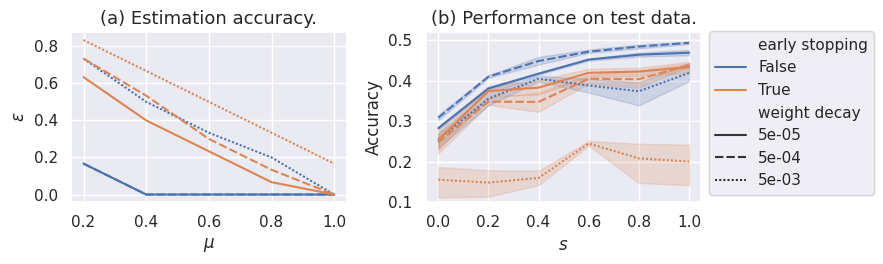

In [169]:

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
fig.set_size_inches(9, 2.8)
sns.set_theme()

early_df = pd.DataFrame.from_dict(df_dict)
early_acc_df = pd.DataFrame.from_dict(acc_df_dict)
sns.lineplot(x='mu', y='epsilon', style='weight decay', hue='early stopping', data=early_df, ax=ax1)
ax1.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax1.set_xlabel("$\mu$")
ax1.set_ylabel("$\epsilon$")
ax1.set_title("(a) Estimation accuracy.", fontsize=13)
ax1.get_legend().remove()

sns.lineplot(x='s', y='accuracy', style='weight decay', hue='early stopping', data=early_acc_df, ax=ax2)
ax2.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax2.set_xlabel("$s$")
ax2.set_ylabel("Accuracy")
ax2.set_ylim([0.1, .52])
# ax3.get_legend().remove()
ax2.set_title("(b) Performance on test data.", fontsize=13)
ax2.legend(bbox_to_anchor=(1.0, 1.05))
# nonearly_acc_df = pd.DataFrame.from_dict(acc_df_dict['nonearly'])
# sns.lineplot(x='s', y='accuracy', style='weight decay', data=nonearly_acc_df, ax=ax4)
# ax4.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
# ax4.set_xlabel("$s$")
# # ax4.set_ylabel("Accuracy")
# ax4.get_legend().remove()

plt.tight_layout()
plt.savefig("early_stopping.pdf", bbox_inches='tight')


# Evaluate Mixmo

In [7]:
sys.path.append("mixmo-pytorch/")
from mixmo.networks import get_network
from mixmo.utils import (misc, config, logger)
config_args = misc.load_config_yaml('mixmo-pytorch/config/tiny/resnet182-2_cutmixmo-p5.yaml')

## Load mixmo networks

In [8]:
loaded_net_dict = {}
for s in target_s_list:
    model_list = []
    for copy_id in range(COPY_NUM):
        checkpoint_path = os.path.join(settings.CASE_STUDY_CHECKPOINT_PATH, 'mixmo_model', f'int_{s}_{copy_id}', "resnet182-2_cutmixmo-p5")
        log = pd.read_csv(os.path.join(checkpoint_path, "logs.csv"))
        ckpt_idx = log.iloc[(log['test/accuracy'].str.strip("%").astype("float")/100).argmax()]['epoch']
        checkpoint = torch.load(os.path.join(checkpoint_path, f'checkpoint_epoch_{ckpt_idx}.ckpt'))
        net = get_network(config_args["model_wrapper"]["network"], config_args)
        
        net.load_state_dict(checkpoint['classifier_state_dict'], strict=True)
        net.eval()
        net = nn.Sequential(transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)), net)
        model_list.append(net)
    loaded_net_dict[f'int{s}'] = model_list

## Process data and table

In [9]:
sys.path.append('../dataset_similarity')
from similarity_cv_predict import sample_intersect1_loader

In [10]:
loader = sample_intersect1_loader('tinyimagenet', 100)
verify_samples = []
for sample, y in loader:
    verify_samples.append(sample)
verify_tensor = torch.cat(verify_samples)

In [11]:
prediction_dict = {}
for intersection, model_list in loaded_net_dict.items():
    
    pred_copy_list = []
    with torch.no_grad():
        for net in model_list:
            pred_copy_list.append(net(verify_tensor)['logits'].softmax(dim=1))
    prediction_dict[intersection] = torch.stack(pred_copy_list)

surrogate_outputs = pickle.load(open(os.path.join(settings.RESULT_PATH, "dataset_similarity", "tinyimagenet_predict_resnet152.pkl"), "rb"))
estimation_accuracy(surrogate_outputs, prediction_dict, target_s_list, target_s_list, copy_num=COPY_NUM)

({0.0: 1.0, 0.2: 0.6333333333333333, 0.4: 0.0, 0.6: 0.0, 0.8: 0.0, 1.0: 0.0},
 array([0.2, 0.2, 0.2, 0. , 0. , 0. , 0.2, 0.2, 0.2, 0.2, 0. , 0. , 0.2,
        0.2, 0.2, 0.2, 0. , 0. , 0.2, 0.2, 0.2, 0.2, 0. , 0. , 0.2, 0.2,
        0.2, 0.2, 0. , 0. ]))

# Show accuracy scores for Mixmo models

In [12]:
X_set, y_set = pickle.load(open(os.path.join(settings.DATA_PATH, 'TinyImagenet_test.pkl'), 'rb'))
tinyimagenet_test = utils.SubTrainDataset(X_set, list(y_set), transform=transforms.ToTensor())
tinyimagenet_test_loader = torch.utils.data.DataLoader(
    tinyimagenet_test, shuffle=False, num_workers=8, batch_size=1024, pin_memory=True)

loss_function = nn.CrossEntropyLoss().cuda()


for key, model_list in loaded_net_dict.items():
    accs = []
    for net in model_list:
        net.cuda()
        preds = []
        for (images, labels) in tinyimagenet_test_loader:
            images = images.cuda()
            labels = labels.cuda()
            outputs = net(images)['logits'].argmax(dim=1)
            preds.extend(outputs.tolist())
        net.cpu()
        accs.append(accuracy_score(tinyimagenet_test_loader.dataset.targets, preds) * 100)
    print(key, accs,)

int0.0 [61.129999999999995, 59.89, 55.87, 60.12, 59.85]
int0.2 [59.77, 60.07, 59.77, 60.31999999999999, 59.84]
int0.4 [59.870000000000005, 60.11, 60.419999999999995, 60.370000000000005, 57.16]
int0.6 [60.150000000000006, 60.129999999999995, 59.85, 60.49, 59.95]
int0.8 [60.3, 60.589999999999996, 60.019999999999996, 60.14000000000001, 60.3]
int1.0 [60.809999999999995, 60.550000000000004, 60.61, 60.089999999999996, 60.6]
